<center><h1>Sentiment Classification with Recurrent Networks: GRU vs. LSTM</h1></center>



## Load the data

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import re
import time
import tensorflow as tf
from google.colab import files

uploaded = files.upload()
tf.random.set_seed(42)

data = pd.read_csv('all_data.csv')
data = data.dropna(subset=['review', 'sentiment']).reset_index(drop=True)
data.head()

Saving all_data.csv to all_data.csv


,review,sentiment
0,Aditya Ingole Deaf,2
1,I love the app.! There is no issue but if u co...,1
2,"So hard to use. The web app failed, and the mo...",0
3,I hate that the app makes a sound every time s...,1
4,Useless at BSE star MF meet.voice too mych slo...,0


In [3]:
data['sentiment'].value_counts()

,count
sentiment,
2,15302
0,13466
1,11748


### Preprocess the text


In [5]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['clean_text'] = data['review'].map(preprocess_text)
data = data[data['clean_text'].str.len() > 0].reset_index(drop=True)
data.shape

(39804, 3)

### Split into train/test

In [6]:
from sklearn.model_selection import train_test_split

x_train_text, x_test_text, y_train, y_test = train_test_split(
    data['clean_text'], data['sentiment'], test_size=0.2, random_state=42, stratify=data['sentiment']
)
y_train = np.array(y_train)
y_test = np.array(y_test)
len(x_train_text), len(x_test_text)

(31843, 7961)

### Build the vocabulary

In [7]:
VOCAB_SIZE = 15000

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train_text)

word2idx = tokenizer.word_index
idx2word = {idx: word for word, idx in word2idx.items()}
print(f"Vocabulary size (all words seen): {len(word2idx)}")

Vocabulary size (all words seen): 14361


In [10]:
x_train_seq = tokenizer.texts_to_sequences(x_train_text)
x_test_seq = tokenizer.texts_to_sequences(x_test_text)

def reconstruct(tokens):
    return " ".join(idx2word.get(t, '<OOV>') for t in tokens)

print(x_train_seq[1])
print(reconstruct(x_train_seq[1]))

[46, 3, 44, 5]
nice i like it


### Let's pad x_train to make sure they are all of the same length

In [11]:
lengths = [len(seq) for seq in x_train_seq]
print(f"Max sequence length in training data: {max(lengths)}")
print(f"95th percentile: {int(np.percentile(lengths, 95))}")

Max sequence length in training data: 234
95th percentile: 62


In [12]:
max_sequence_len = 60

x_train_padded = tf.keras.preprocessing.sequence.pad_sequences(
    x_train_seq, maxlen=max_sequence_len, padding='post', truncating='post'
)
x_test_padded = tf.keras.preprocessing.sequence.pad_sequences(
    x_test_seq, maxlen=max_sequence_len, padding='post', truncating='post'
)
x_train_padded.shape, x_test_padded.shape

((31843, 60), (7961, 60))

## build the models


In [13]:
EMBED_DIM = 64
RNN_UNITS = 64

def build_gru_model():
    return tf.keras.models.Sequential([
        tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM),
        tf.keras.layers.Bidirectional(tf.keras.layers.GRU(RNN_UNITS)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

def build_lstm_model():
    return tf.keras.models.Sequential([
        tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(RNN_UNITS)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

### Train the GRU model

In [16]:
gru_model = build_gru_model()

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()

gru_history = gru_model.fit(
    x_train_padded,
    y_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test_padded, y_test),
    shuffle=True,
    verbose=1
)

gru_train_time = time.time() - t0

print(f"\nGRU training time: {gru_train_time:.2f} seconds")
print(f"GRU parameters: {gru_model.count_params():,}")

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 49s 350ms/step - accuracy: 0.5591 - loss: 0.9163 - val_accuracy: 0.6307 - val_loss: 0.8108
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 83s 356ms/step - accuracy: 0.6726 - loss: 0.7536 - val_accuracy: 0.6581 - val_loss: 0.7782
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 346ms/step - accuracy: 0.7197 - loss: 0.6725 - val_accuracy: 0.6596 - val_loss: 0.7974
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 344ms/step - accuracy: 0.7480 - loss: 0.6123 - val_accuracy: 0.6639 - val_loss: 0.8376
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 345ms/step - accuracy: 0.7721 - loss: 0.5660 - val_accuracy: 0.6668 - val_loss: 0.8849

GRU training time: 300.69 seconds
GRU parameters: 1,018,371


In [17]:
gru_test_loss, gru_test_acc = gru_model.evaluate(x_test_padded, y_test, verbose=0)
print(f"GRU -> Test Loss: {gru_test_loss:.4f}, Test Accuracy: {gru_test_acc:.4f}")

GRU -> Test Loss: 0.8849, Test Accuracy: 0.6668


### Train the LSTM model

In [19]:
lstm_model = build_lstm_model()
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
t0 = time.time()

lstm_history = lstm_model.fit(
    x_train_padded,
    y_train,
    epochs=3,
    batch_size=256,
    validation_data=(x_test_padded, y_test),
    shuffle=True,
    verbose=1
)

lstm_train_time = time.time() - t0

print(f"\nLSTM training time: {lstm_train_time:.2f} seconds")
print(f"LSTM parameters: {lstm_model.count_params():,}")

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 321ms/step - accuracy: 0.5376 - loss: 0.9575 - val_accuracy: 0.6239 - val_loss: 0.8297
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 308ms/step - accuracy: 0.6575 - loss: 0.7772 - val_accuracy: 0.6415 - val_loss: 0.7820
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 327ms/step - accuracy: 0.7055 - loss: 0.6965 - val_accuracy: 0.6549 - val_loss: 0.7788

LSTM training time: 123.26 seconds
LSTM parameters: 1,034,499


In [20]:
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(x_test_padded, y_test, verbose=0)
print(f"LSTM -> Test Loss: {lstm_test_loss:.4f}, Test Accuracy: {lstm_test_acc:.4f}")

LSTM -> Test Loss: 0.7788, Test Accuracy: 0.6549


## Compare GRU vs. LSTM

In [21]:
from sklearn.metrics import f1_score, classification_report

gru_pred = np.argmax(gru_model.predict(x_test_padded, verbose=0), axis=1)
lstm_pred = np.argmax(lstm_model.predict(x_test_padded, verbose=0), axis=1)

gru_f1 = f1_score(y_test, gru_pred, average='macro')
lstm_f1 = f1_score(y_test, lstm_pred, average='macro')

comparison = pd.DataFrame({
    'Model': ['GRU', 'LSTM'],
    'Test Accuracy': [gru_test_acc, lstm_test_acc],
    'Macro F1': [gru_f1, lstm_f1],
    'Parameters': [gru_model.count_params(), lstm_model.count_params()],
    'Training Time (s)': [round(gru_train_time, 1), round(lstm_train_time, 1)]
})
comparison

,Model,Test Accuracy,Macro F1,Parameters,Training Time (s)
0,GRU,0.666750,0.639678,1018371,300.7
1,LSTM,0.654943,0.624740,1034499,123.3


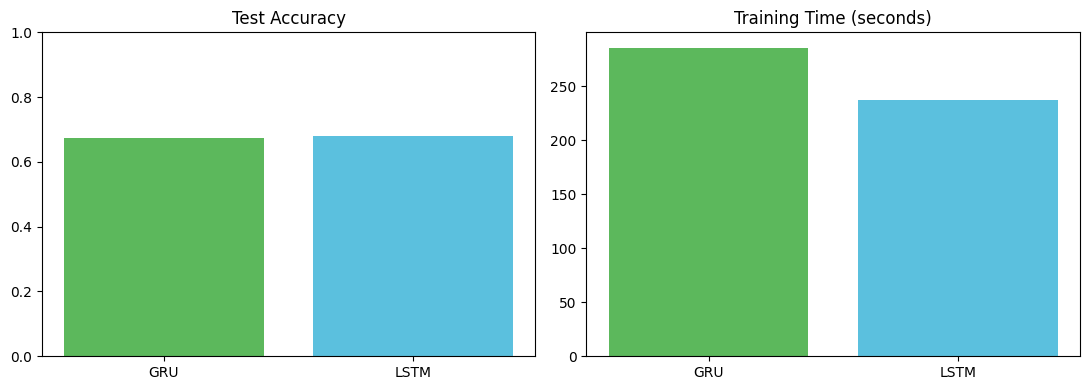

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['GRU', 'LSTM'], [gru_test_acc, lstm_test_acc], color=['#5cb85c', '#5bc0de'])
axes[0].set_title('Test Accuracy')
axes[0].set_ylim(0, 1)

axes[1].bar(['GRU', 'LSTM'], [gru_train_time, lstm_train_time], color=['#5cb85c', '#5bc0de'])
axes[1].set_title('Training Time (seconds)')

plt.tight_layout()
plt.show()

In [22]:
print("GRU classification report:")
print(classification_report(y_test, gru_pred))
print("LSTM classification report:")
print(classification_report(y_test, lstm_pred))

GRU classification report:
              precision    recall  f1-score   support

           0       0.67      0.74      0.70      2657
           1       0.59      0.38      0.46      2302
           2       0.70      0.82      0.75      3002

    accuracy                           0.67      7961
   macro avg       0.65      0.65      0.64      7961
weighted avg       0.66      0.67      0.65      7961

LSTM classification report:
              precision    recall  f1-score   support

           0       0.64      0.77      0.70      2657
           1       0.55      0.34      0.42      2302
           2       0.71      0.79      0.75      3002

    accuracy                           0.65      7961
   macro avg       0.63      0.64      0.62      7961
weighted avg       0.64      0.65      0.64      7961



> run the next cell to store the models

In [23]:
os.makedirs('models', exist_ok=True)
gru_model.save('models/gru_model.keras')
lstm_model.save('models/lstm_model.keras')
print("Models saved.")

Models saved.


### How can we predict an input given these models?

In [24]:
def predict(text, model, tokenizer_obj, padding_size):
    clean = preprocess_text(text)
    seq = tokenizer_obj.texts_to_sequences([clean])
    padded = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=padding_size, padding='post', truncating='post')
    proba = model.predict(padded, verbose=0)[0]
    mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
    pred_class = mapping[int(np.argmax(proba))]
    return pred_class, {mapping[i]: round(float(p), 3) for i, p in enumerate(proba)}

In [25]:
text = "the app used to work fine but after the last update it keeps crashing and losing my chats"

print("GRU  :", predict(text, gru_model, tokenizer, max_sequence_len))
print("LSTM :", predict(text, lstm_model, tokenizer, max_sequence_len))

GRU  : ('negative', {'negative': 0.77, 'neutral': 0.203, 'positive': 0.027})
LSTM : ('negative', {'negative': 0.565, 'neutral': 0.36, 'positive': 0.075})


In [26]:
text2 = "amazing update, video calls are so much clearer now, thank you!"

print("GRU  :", predict(text2, gru_model, tokenizer, max_sequence_len))
print("LSTM :", predict(text2, lstm_model, tokenizer, max_sequence_len))

GRU  : ('positive', {'negative': 0.001, 'neutral': 0.003, 'positive': 0.996})
LSTM : ('positive', {'negative': 0.005, 'neutral': 0.019, 'positive': 0.976})
